In [1]:
import torch

torch.cuda.empty_cache()

In [2]:
# -*- coding: utf-8 -*-
from dreal import *
# from Functions import *
import torch 
import torch.nn.functional as F
import numpy as np
import timeit 
import matplotlib.pyplot as plt
import torch.nn as nn
import random
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm

In [3]:
torch.manual_seed(17)

random.seed()



In [4]:
device = torch.device("cuda:1" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


In [5]:
numerical_x = torch.Tensor(500, 2).uniform_(-1, 1).float()
numerical_x = numerical_x.to(device)  

In [6]:
def checkSMTconstraints(vars,a_learnt,divergence_learnt, ball_lb, ball_ub, config, epsilon=0):
    """ Check the SMT constraints for the given variables and learnt parameters. """
    ball = Expression(0)

    # construct ball constraint
    for i in range(len(vars)):
        ball += vars[i]**2
    ball_in_bound = logical_and(ball >= ball_lb, ball <= ball_ub)

    # condition on a
    a_condition = a_learnt >= 0
    divergence_condition = divergence_learnt > 0
    stability_condition = logical_and(
        logical_imply(ball_in_bound, divergence_condition),
        logical_imply(ball_in_bound, a_condition)
    )

    # check satisfiability of the negation of the condition
    return CheckSatisfiability(logical_not(stability_condition), config)


def AddCounterexamples(x, CE, N, device):
    """
    Adds counterexamples to the sample set `x`.
    
    Args:
        x: Existing tensor of samples.
        CE: Counterexample intervals from `Checkdivergence`.
        N: Number of nearby points to add for each counterexample.
        device: Device where tensors are stored (e.g., `cuda:1`).

    Returns:
        Updated tensor with counterexamples added.
    """
    nearby = []
    for i in range(CE.size()):
        lb = CE[i].lb()
        ub = CE[i].ub()
        nearby_ = np.random.uniform(lb, ub, N)  # Generate nearby points
        nearby.append(nearby_)
    
    for i in range(N):
        n_pt = []
        for j in range(x.shape[1]):
            n_pt.append(nearby[j][i])  # Collect one point from each dimension
        # Add the point to `x` on the correct device
        n_pt_tensor = torch.tensor([n_pt], dtype=torch.float32, device=device)
        x = torch.cat((x, n_pt_tensor), dim=0)
        x= torch.unique(x, dim=0)

    return x, n_pt_tensor

In [7]:
import math

def f_value(f_val, g_val, u):
    """
    The dynamical system is defined as f(x)+g(x)u
    where f(x) and g(x) are functions of x and u is the control
    input. This function returns the value of the dynamical system
    at x with control input u.
    """
    return f_val + g_val * u

def f(x):
    v = 6.0
    L = 1.0
    kappa = 1.0  # curvature for unit circle
    de = x[0]
    theta_e = x[1]
    denom = 1 - de * kappa
    return torch.tensor([
        v * torch.sin(theta_e),
        -1 *  torch.cos(theta_e) / denom
    ], device=device)

def g(x):
    v = 6.0
    L = 1.0
    return torch.tensor([
        0.0,
        v / L
    ], device=device)




In [8]:
class polynomial_net(nn.Module):
    """ this class is used to define the neural network which we intent to approximate a polynomial function"""
    def __init__(self, input_dim, hidden_dim, output_dim):
        super(polynomial_net, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, output_dim)
        )
        self._initialize_weights()

    def _initialize_weights(self):
        for layer in self.net:
            if isinstance(layer, nn.Linear):
                nn.init.xavier_uniform_(layer.weight)
                nn.init.zeros_(layer.bias)

    def forward(self, x):
        return self.net(x)

class polynomial_net_bias_Zero(nn.Module):
    """ this class is used to define the neural network which we intent to approximate a polynomial function"""
    def __init__(self, input_dim, hidden_dim, output_dim):
        super(polynomial_net_bias_Zero, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, output_dim)
        )
        self._initialize_weights()

    def _initialize_weights(self):
        for layer in self.net:
            if isinstance(layer, nn.Linear):
                nn.init.xavier_uniform_(layer.weight)
                nn.init.zeros_(layer.bias)  # set bias to zero
                layer.bias.requires_grad = False  # freeze bias to stay zero


    def forward(self, x):
        return self.net(x)
    
class numerator_polynomial_net(nn.Module):
    """ this class is used to define the neural network which we intent to approximate a polynomial function"""
    def __init__(self, input_dim, hidden_dim, output_dim):
        super(numerator_polynomial_net, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.Sigmoid(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Sigmoid(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Sigmoid(),
            nn.Linear(hidden_dim, output_dim),
            nn.Sigmoid()
        )
        self._initialize_weights()

    def _initialize_weights(self):
        for layer in self.net:
            if isinstance(layer, nn.Linear):
                nn.init.xavier_uniform_(layer.weight)
                nn.init.zeros_(layer.bias)

    def forward(self, x):
        return self.net(x)

class FixedDenominatorNet(nn.Module):
    def __init__(self):
        super(FixedDenominatorNet, self).__init__()

    def forward(self, x):
        # Compute e^{||x||^2}
        norm_squared = torch.sum(x ** 2, dim=1, keepdim=True)  
        return torch.exp(norm_squared)
     
class GammaFunctionNet(nn.Module):
    def __init__(self, input_dim, output_dim):
        super(GammaFunctionNet, self).__init__()
        self.linear_layer = nn.Linear(input_dim, output_dim)
        
        # Initialize weights to zero and bias to zero (or any desired value)
        nn.init.constant_(self.linear_layer.weight, 0)
        nn.init.constant_(self.linear_layer.bias, 0)

        # Freeze weights to ensure they cannot be updated
        self.linear_layer.weight.requires_grad = False

    def forward(self, x):
        # Directly return the bias as output
        return self.linear_layer.bias



In [9]:
def gradient_at_given_function(func,x):
    """ The function returns the gradient of given function at x"""
    # Ensure x requires gradients
    x = x.clone().detach().requires_grad_(True)
    
   # Compute the output of the function
    output = func(x.unsqueeze(0))  # Add batch dimension (shape: [1, input_dim])
    
    # Extract scalar from output tensor
    output = output.squeeze()  # Remove batch and channel dimensions (shape: ())
    
    # Ensure the function returns a scalar
    if output.dim() != 0:
        raise ValueError(f"The function must return a scalar value, but got shape {output.shape}.")
    
    # Compute the gradient
    grad = torch.autograd.grad(outputs=output, inputs=x, create_graph=True)[0]
    
    return grad


def gradient_at_given_function_special_b(func, x):
    """
    This function returns the gradient of f^T f at x.
    Here, f: R^n → R^d, and we wish to return the gradient of f^T f at x.
    
    The idea:
    - Compute output = f(x), which is a vector in R^d.
    - Compute squared norm: output_norm_squared = ||f(x)||^2 = f^T f.
    - Compute gradient of output_norm_squared w.r.t. x.
    """
    # Ensure x requires gradients
    x = x.clone().detach().requires_grad_(True)
    
    # Compute f(x)
    output = func(x.unsqueeze(0))  # Add batch dimension (shape: [1, input_dim])
    
    # Remove batch dimension to get shape [d]
    output = output.squeeze(0)
    
    # Check that output is a vector (1D)
    if output.dim() != 1:
        raise ValueError(f"The function must return a vector value (shape [d]), but got shape {output.shape}.")
    
    # Compute f^T f = ||f(x)||^2
    output_norm_squared = torch.sum(output ** 2)
    
    # Compute the gradient w.r.t. x
    grad = torch.autograd.grad(outputs=output_norm_squared, inputs=x, create_graph=True)[0]
    
    return grad



def div_f(x):
    # x[0] = d_e, x[1] = theta_e
    v = 1.0  # choose your vehicle speed
    kappa = 1.0  # curvature of path (for unit circle, kappa=1/R=1)
    D = 1 - x[0] * kappa
    divergence = (v * kappa * torch.sin(x[1])) / D
    return divergence

def div_g(x):
    return torch.tensor(0.0, device=device)


def control_density_risk(x, f_fun, g_fun, a_fun, b_fun, c_fun):
    ret_val = []
    for i in range(x.shape[0]):
        divergence_at_f = div_f(x[i])
        divergence_at_g = div_g(x[i])
        grad_at_a = gradient_at_given_function(a_fun, x[i])
        grad_at_c = gradient_at_given_function(c_fun, x[i])
        grad_at_b = gradient_at_given_function_special_b(b_fun, x[i])
        # square root of x^Tx
        
        a_vals = a_fun(x[i])
        # b_vals = b_fun(x[i])
        c_vals = c_fun(x[i])
        f_vals = f_fun(x[i])
        g_vals = g_fun(x[i])
        term1 = a_vals * divergence_at_f + divergence_at_g * c_vals + grad_at_a.T @ f_vals + grad_at_c.T @ g_vals
        term2 = (2 * x[i] + grad_at_b) @ (f_vals * a_vals + g_vals * c_vals)
        term = term1 - term2
        ret_val.append(term)
    ret_val = torch.stack(ret_val)
    return ret_val 



In [10]:
def control_density_loss(x, f_fun, g_fun, a_fun, b_fun, c_fun, gamma_fun, lambda_center=1, lambda_decay=1):
    """
    Compute the control density loss with additional center and decay regularization.

    Args:
        x: Input tensor.
        f_fun: Function representing f(x).
        g_fun: Function representing g(x).
        a_fun: Function representing a(x).
        b_fun: Function representing b(x).
        c_fun: Function representing c(x).
        gamma_fun: Function representing gamma(x).
        lambda_center: Weight for center-maximizing term.
        lambda_decay: Weight for decay-penalizing term.

    Returns:
        Total control density loss value.
    """
    divergence = control_density_risk(x, f_fun, g_fun, a_fun, b_fun, c_fun)
    loss = F.relu(gamma_fun(x) - divergence).mean()
    a_loss = F.relu(-a_fun(x)).mean()
    gamma_loss = F.relu(-gamma_fun(x)).mean()
      
    total_loss = loss + a_loss + gamma_loss 
    return total_loss


In [11]:
class activSymbolicNN:
    """
    A helper class to convert neural networks to symbolic expressions for dReal.
    """
    def __init__(self, net):
        """Initialize with a PyTorch neural network"""
        self.weights = []
        self.biases = []
        self.extract_params(net)

    def extract_params(self, net):
        """Extract weights and biases from PyTorch network"""
        for layer in net.net:
            if isinstance(layer, nn.Linear):
                self.weights.append(layer.weight.detach().cpu().numpy())
                if layer.bias is not None:
                    self.biases.append(layer.bias.detach().cpu().numpy())

    def forward_symbolic(self, vars):
        """
        Compute symbolic forward pass.
        Args:
            vars: List of dReal Variables
        Returns:
            Symbolic expression for network output
        """
        z = vars
        for i in range(len(self.weights)):
            # Linear transformation
            z = self._linear_symbolic(z, self.weights[i], self.biases[i])
            # # Apply tanh activation
            # z = [tanh(zi) for zi in z]
            # Apply sigmoid activation
            z = [(1/(1 + exp(-zi))) for zi in z]
        
        # # Final linear layer without activation
        # z = self._linear_symbolic(z, self.weights[-1], self.biases[-1])
        return z

    def _linear_symbolic(self, x, weight, bias):
        """
        Compute symbolic linear transformation.
        Args:
            x: Input symbolic expressions
            weight: Weight matrix
            bias: Bias vector
        Returns:
            List of symbolic expressions
        """
        out = []
        for i in range(weight.shape[0]):  # For each output dimension
            expr = bias[i]
            for j in range(weight.shape[1]):  # For each input dimension
                expr += weight[i,j] * x[j]
            out.append(expr)
        return out


In [12]:
class SymbolicNN:
    """
    A helper class to convert neural networks to symbolic expressions for dReal.
    """
    def __init__(self, net):
        """Initialize with a PyTorch neural network"""
        self.weights = []
        self.biases = []
        self.extract_params(net)

    def extract_params(self, net):
        """Extract weights and biases from PyTorch network"""
        for layer in net.net:
            if isinstance(layer, nn.Linear):
                self.weights.append(layer.weight.detach().cpu().numpy())
                if layer.bias is not None:
                    self.biases.append(layer.bias.detach().cpu().numpy())

    def forward_symbolic(self, vars):
        """
        Compute symbolic forward pass.
        Args:
            vars: List of dReal Variables
        Returns:
            Symbolic expression for network output
        """
        z = vars
        for i in range(len(self.weights) - 1):
            # Linear transformation
            z = self._linear_symbolic(z, self.weights[i], self.biases[i])
            # Apply tanh activation
            z = [tanh(zi) for zi in z]
            # # Apply sigmoid activation
            # z = [(1/(1 + exp(-zi))) for zi in z]
        
        # Final linear layer without activation
        z = self._linear_symbolic(z, self.weights[-1], self.biases[-1])
        return z

    def _linear_symbolic(self, x, weight, bias):
        """
        Compute symbolic linear transformation.
        Args:
            x: Input symbolic expressions
            weight: Weight matrix
            bias: Bias vector
        Returns:
            List of symbolic expressions
        """
        out = []
        for i in range(weight.shape[0]):  # For each output dimension
            expr = bias[i]
            for j in range(weight.shape[1]):  # For each input dimension
                expr += weight[i,j] * x[j]
            out.append(expr)
        return out


In [13]:
def candidate_constraint_learnt(vars,a_fun,b_fun,c_fun):
    """
    Construct candidate constraints for the learnt functions.
    
    Args:
        vars: List of dReal Variables
        a_fun: Function representing a(x).
        b_fun: Function representing b(x).
        c_fun: Function representing c(x).

    Returns:
        Symbolic expression for the candidate constraint.
    """
    a_sym = activSymbolicNN(a_fun).forward_symbolic(vars)[0]
    b_sym = SymbolicNN(b_fun).forward_symbolic(vars)
    c_sym = SymbolicNN(c_fun).forward_symbolic(vars)[0]

    # b_sym = ||b_sym||^2
    b_sym = sum([bi**2 for bi in b_sym])


    # write f and g in terms of val
    v = 1.0  # speed
    kappa = 1.0  # curvature 
    L = 2.0  # length of the vehicle
    D = 1 - vars[0] * kappa  # D = 1 - d_e * kappa

    f_val = [
        v * sin(vars[1]),
        - (v * kappa * cos(vars[1])) / D
    ]
    g_val = [
        0,
        v / L
    ]

    f_div = (v * kappa * sin(vars[1])) / D
    g_div = 0



    grad_a = [a_sym.Differentiate(vars[i]) for i in range(len(vars))]
    grad_c = [c_sym.Differentiate(vars[i]) for i in range(len(vars))]
    grad_b = [b_sym.Differentiate(vars[i]) for i in range(len(vars))]

    constraint1 = a_sym * f_div + g_div * c_sym + sum([grad_a[i] * f_val[i] for i in range(len(f_val))]) + sum([grad_c[i] * g_val[i] for i in range(len(g_val))])
  
    scaled_vars = [2 * var_i for var_i in vars]
    constraint2 = [scaled_vars[i] + grad_b[i] for i in range(len(vars))]

    constraint2 = sum([constraint2[i] * (f_val[i] * a_sym + g_val[i] * c_sym) for i in range(len(f_val))])  
    constraint = constraint1 - constraint2
    return a_sym , constraint


In [14]:
config = Config()
config.use_polytope_in_forall = True
config.use_local_optimization = True
config.precision = 1e-5
epsilon = 0

ball_lb = 0.5
ball_ub = 1
x1 = Variable("x1")
x2 = Variable("x2")


In [15]:
def train_density(x,epochs=2000, lr=1e-2):
    loss_total_density = []
    # Define the neural networks
    a_net = numerator_polynomial_net(2, 6, 1).to(device)
    c_net = polynomial_net(2, 6, 1).to(device)
    b_net = polynomial_net_bias_Zero(2, 6, 2).to(device)
    gamma_net = GammaFunctionNet(2, 1).to(device)

    # Define the optimizer
    optimizer = torch.optim.RMSprop(list(a_net.parameters()) + list(c_net.parameters()) + list(b_net.parameters()) + list(gamma_net.parameters()), lr=lr)

    valid = False
    print("Training density function")
    while not valid :
        for epoch in range(epochs):
            optimizer.zero_grad()
            # compute the loss
            loss = control_density_loss(x, f, g, a_net, b_net, c_net, gamma_net)
            loss_total_density.append(loss.item())
            # backpropagation
            loss.backward()
            # update the parameters
            optimizer.step()
            
            if loss.item() == 0:
                # # Check for counterexamples
                # vars = [Variable("x1"), Variable("x2")]
                # a_learnt, divergence_learnt = candidate_constraint_learnt(vars, a_net, b_net, c_net)
                # CE = checkSMTconstraints(vars, a_learnt, divergence_learnt, ball_lb, ball_ub, config)
                # if (CE):
                #     print("Counterexample found!")
                #     x, n_pt_tensor = AddCounterexamples(x, CE, 100, device)
                # else:
                valid = True 
                print("No counterexample found.")
                break

            if loss.item() < 5e-3:
                valid = True
                break

            print(f"Epoch {epoch}/{epochs}, Loss: {loss.item():.4f}")
            if epoch % 100 == 0:
                # Check for counterexamples
                vars = [Variable("x1"), Variable("x2")]
                a_learnt, divergence_learnt = candidate_constraint_learnt(vars, a_net, b_net, c_net)
                CE = checkSMTconstraints(vars, a_learnt, divergence_learnt, ball_lb, ball_ub, config)
                if (CE):
                    print("Counterexample found!")
                    x, n_pt_tensor = AddCounterexamples(x, CE, 100, device)
                else:
                    valid = True 
                    print("No counterexample found.")
                    break
    print(f"Final Loss: {loss.item():.4f}")
    print(f"The learned margin is {gamma_net(torch.tensor([0,0], dtype=torch.float32, device=device))}")
    return loss_total_density, a_net, b_net, c_net, gamma_net


In [16]:
def plot_results(risks, labels):
    plt.figure(figsize=(10, 6))
    for risk, label in zip(risks, labels):
        plt.plot(risk, label=label)
    plt.xlabel("Iteration")
    plt.ylabel("Risk")
    plt.title("Risk Over Iterations")
    plt.legend()
    plt.grid()
    plt.show()


In [77]:
loss_density, a_ret, b_ret, c_ret, gamma_net = train_density(numerical_x, epochs=2000, lr=1e-2)

Training density function
Epoch 0/2000, Loss: 1.5728
Counterexample found!
Epoch 1/2000, Loss: 5.5073
Epoch 2/2000, Loss: 1.4364
Epoch 3/2000, Loss: 0.5072
Epoch 4/2000, Loss: 0.5884
Epoch 5/2000, Loss: 0.2429
Epoch 6/2000, Loss: 0.4817
Epoch 7/2000, Loss: 0.1716
Epoch 8/2000, Loss: 0.1497
Epoch 9/2000, Loss: 0.1583
Epoch 10/2000, Loss: 0.1834
Epoch 11/2000, Loss: 0.3598
Epoch 12/2000, Loss: 0.2580
Epoch 13/2000, Loss: 0.2130
Epoch 14/2000, Loss: 0.1790
Epoch 15/2000, Loss: 0.1847
Epoch 16/2000, Loss: 0.1773
Epoch 17/2000, Loss: 0.1930
Epoch 18/2000, Loss: 0.1450
Epoch 19/2000, Loss: 0.1512
Epoch 20/2000, Loss: 0.1457
Epoch 21/2000, Loss: 0.1766
Epoch 22/2000, Loss: 0.2027
Epoch 23/2000, Loss: 0.1296
Epoch 24/2000, Loss: 0.1090
Epoch 25/2000, Loss: 0.1012
Epoch 26/2000, Loss: 0.1356
Epoch 27/2000, Loss: 0.1536
Epoch 28/2000, Loss: 0.0961
Epoch 29/2000, Loss: 0.0874
Epoch 30/2000, Loss: 0.1185
Epoch 31/2000, Loss: 0.1425
Epoch 32/2000, Loss: 0.1537
Epoch 33/2000, Loss: 0.0930
Epoch 34/2

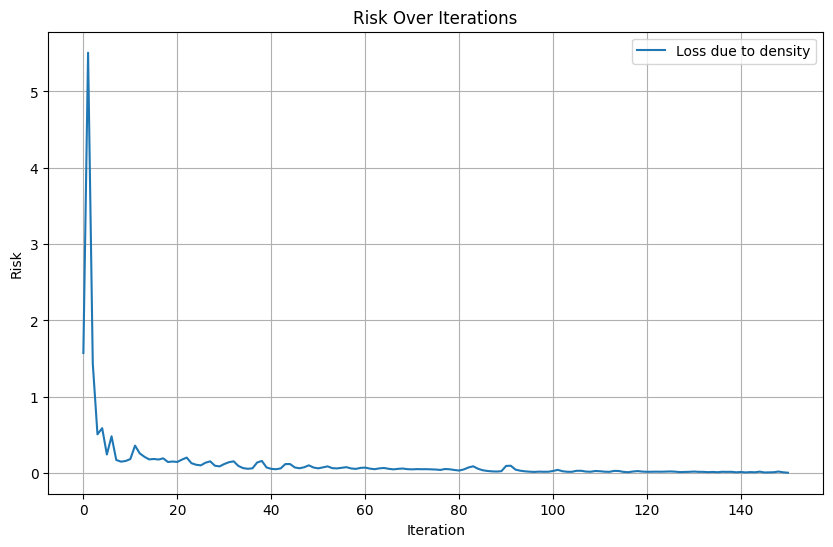

In [78]:

risks = []
risks.append(loss_density)

plot_results(risks, labels=[f"Loss due to {d}" for d in ['density']])


In [79]:
grid_size = 100
# Define grid for x1 and x2
x1 = torch.linspace(-1, 1, grid_size)
x2 = torch.linspace(-1, 1, grid_size)
x1_grid, x2_grid = torch.meshgrid(x1, x2)
grid_points = torch.stack([x1_grid.ravel(), x2_grid.ravel()], dim=1).to(device)


In [80]:
rho_set = a_ret(grid_points)/ (torch.exp( torch.sum(grid_points**2, dim=1, keepdim=True) + torch.sum((b_ret(grid_points))**2, dim=1, keepdim=True)))


# # Compute violations set: element-wise min of rho_set and divergence_set
# violations_set = torch.minimum(rho_set, divergence_set)
violations_set = rho_set
# # Convert to binary values: 1 for violation, -1 for satisfaction
# violations_set = torch.where(violations_set <= 0, 1, -1)

# Move to CPU and convert to NumPy for visualization
violations_set = violations_set.detach().cpu().numpy().reshape(grid_size, grid_size)


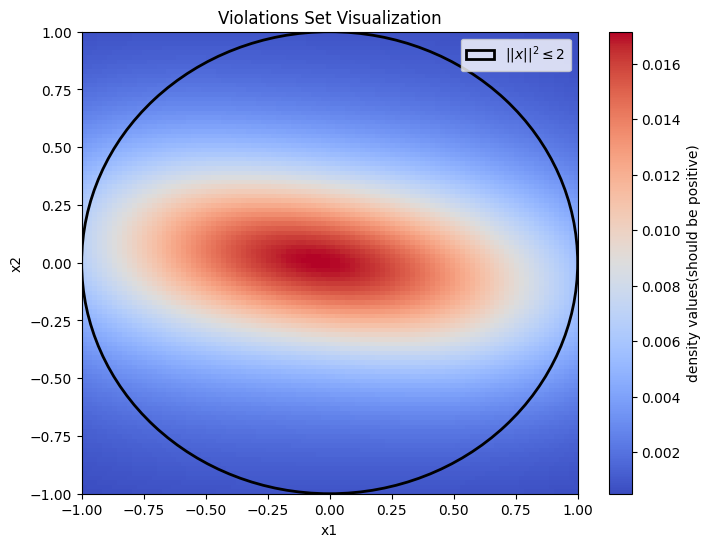

In [81]:
import matplotlib.patches as patches

# Plot heatmap
plt.figure(figsize=(8, 6))
plt.imshow(
    violations_set,
    extent=[-1, 1, -1, 1],
    origin='lower',
    cmap='coolwarm',
    aspect='auto'
)
plt.colorbar(label="density values(should be positive)")
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Violations Set Visualization")

# Add a circle to the plot
circle = patches.Circle((0, 0), 1, color='black', fill=False, linewidth=2, label="$||x||^2 \leq 2$")
plt.gca().add_patch(circle)

# Add legend for the circle
plt.legend(loc='upper right')

plt.grid(False)
plt.show()


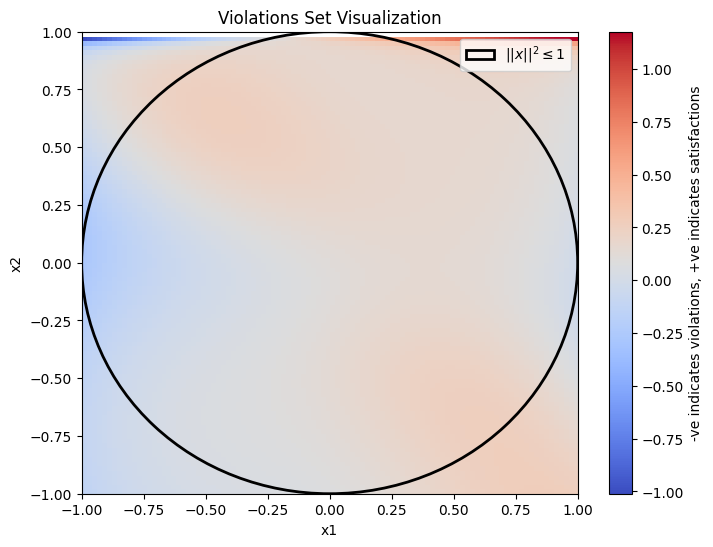

In [82]:
divergence_set = control_density_risk(grid_points, f, g, a_ret, b_ret, c_ret)

violations_set = divergence_set
# # # Convert to binary values: 1 for violation, -1 for satisfaction
# violations_set = torch.where(violations_set <= 0, 1, -1)

# Move to CPU and convert to NumPy for visualization
violations_set = violations_set.detach().cpu().numpy().reshape(grid_size, grid_size)




import matplotlib.patches as patches

# Plot heatmap
plt.figure(figsize=(8, 6))
plt.imshow(
    violations_set,
    extent=[-1, 1, -1, 1],
    origin='lower',
    cmap='coolwarm',
    aspect='auto'
)
plt.colorbar(label="-ve indicates violations, +ve indicates satisfactions")
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Violations Set Visualization")

# Add a circle to the plot
circle = patches.Circle((0, 0), 1, color='black', fill=False, linewidth=2, label="$||x||^2 \leq 1$")
plt.gca().add_patch(circle)

# Add legend for the circle
plt.legend(loc='upper right')

plt.grid(False)
plt.show()


In [85]:
torch.save(a_ret.state_dict(), 'learnt_a_path_tracking.pth')
torch.save(b_ret.state_dict(), 'learnt_b_path_tracking.pth')
torch.save(c_ret.state_dict(), 'learnt_c_path_tracking.pth')

# With new random initialization

In [86]:
# get some fresh data 
torch.manual_seed(7)
random.seed()
numerical_x = torch.Tensor(1000, 2).uniform_(-1, 1).float()
numerical_x = numerical_x.to(device)

loss_density, a_ret, b_ret, c_ret, gamma_net = train_density(numerical_x, epochs=2000, lr=1e-2)

Training density function


Epoch 0/2000, Loss: 3.2863
Counterexample found!
Epoch 1/2000, Loss: 2.5086
Epoch 2/2000, Loss: 3.2196
Epoch 3/2000, Loss: 2.1081
Epoch 4/2000, Loss: 0.9065
Epoch 5/2000, Loss: 0.6126
Epoch 6/2000, Loss: 0.5587
Epoch 7/2000, Loss: 0.9053
Epoch 8/2000, Loss: 0.4980
Epoch 9/2000, Loss: 0.4376
Epoch 10/2000, Loss: 0.5725
Epoch 11/2000, Loss: 0.4278
Epoch 12/2000, Loss: 0.4125
Epoch 13/2000, Loss: 0.4443
Epoch 14/2000, Loss: 0.2836
Epoch 15/2000, Loss: 0.4051
Epoch 16/2000, Loss: 0.2365
Epoch 17/2000, Loss: 0.3528
Epoch 18/2000, Loss: 0.2124
Epoch 19/2000, Loss: 0.3063
Epoch 20/2000, Loss: 0.1784
Epoch 21/2000, Loss: 0.2743
Epoch 22/2000, Loss: 0.1595
Epoch 23/2000, Loss: 0.2232
Epoch 24/2000, Loss: 0.1534
Epoch 25/2000, Loss: 0.2059
Epoch 26/2000, Loss: 0.1108
Epoch 27/2000, Loss: 0.1691
Epoch 28/2000, Loss: 0.0995
Epoch 29/2000, Loss: 0.0912
Epoch 30/2000, Loss: 0.0877
Epoch 31/2000, Loss: 0.1498
Epoch 32/2000, Loss: 0.0770
Epoch 33/2000, Loss: 0.0663
Epoch 34/2000, Loss: 0.0599
Epoch 35

In [88]:
torch.save(a_ret.state_dict(), 'learnt_a_path_tracking_2.pth')
torch.save(b_ret.state_dict(), 'learnt_b_path_tracking_2.pth')
torch.save(c_ret.state_dict(), 'learnt_c_path_tracking_2.pth')

In [14]:

# Define model dimensions
INPUT_DIM = 2
HIDDEN_DIM = 6
# Output dimensions based on your original code
A_OUTPUT_DIM = 1
B_OUTPUT_DIM = 2
C_OUTPUT_DIM = 1


In [15]:
# load the trained weights here for u_1 and \rho_1

# Instantiate the models
a_net = numerator_polynomial_net(INPUT_DIM, HIDDEN_DIM, A_OUTPUT_DIM).to(device)
b_net = polynomial_net_bias_Zero(INPUT_DIM, HIDDEN_DIM, B_OUTPUT_DIM).to(device)
c_net = polynomial_net(INPUT_DIM, HIDDEN_DIM, C_OUTPUT_DIM).to(device)

# Load the state dictionaries from the saved files
# Make sure the .pth files are in the same directory as your notebook, or provide the full path.
try:
    a_net.load_state_dict(torch.load('Model_Paths/learnt_a_path_tracking.pth', map_location=device))
    b_net.load_state_dict(torch.load('Model_Paths/learnt_b_path_tracking.pth', map_location=device))
    c_net.load_state_dict(torch.load('Model_Paths/learnt_c_path_tracking.pth', map_location=device))
    print("Successfully loaded all model weights.")
except FileNotFoundError as e:
    print(f"Error loading model weights: {e}")
    print("Please make sure the .pth files are in the correct directory.")
    # Exit or handle the error appropriately
    exit()

Successfully loaded all model weights.


/tmp/ipykernel_91269/4105290330.py:11: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  a_net.load_state_dict(torch.load('Model_Paths/learnt_a_path_tracking.pth', map_location=

In [16]:

# Set models to evaluation mode. This is important for inference.
a_net.eval()
b_net.eval()
c_net.eval()


polynomial_net(
  (net): Sequential(
    (0): Linear(in_features=2, out_features=6, bias=True)
    (1): Tanh()
    (2): Linear(in_features=6, out_features=6, bias=True)
    (3): Tanh()
    (4): Linear(in_features=6, out_features=6, bias=True)
    (5): Tanh()
    (6): Linear(in_features=6, out_features=1, bias=True)
  )
)

In [17]:
# load the trained weights here for u_1 and \rho_1

# Instantiate the models
a_net1 = numerator_polynomial_net(INPUT_DIM, HIDDEN_DIM, A_OUTPUT_DIM).to(device)
b_net1 = polynomial_net_bias_Zero(INPUT_DIM, HIDDEN_DIM, B_OUTPUT_DIM).to(device)
c_net1 = polynomial_net(INPUT_DIM, HIDDEN_DIM, C_OUTPUT_DIM).to(device)

# Load the state dictionaries from the saved files
# Make sure the .pth files are in the same directory as your notebook, or provide the full path.
try:
    a_net1.load_state_dict(torch.load('Model_Paths/learnt_a_path_tracking_2.pth', map_location=device))
    b_net1.load_state_dict(torch.load('Model_Paths/learnt_b_path_tracking_2.pth', map_location=device))
    c_net1.load_state_dict(torch.load('Model_Paths/learnt_c_path_tracking_2.pth', map_location=device))
    print("Successfully loaded all model weights.")
except FileNotFoundError as e:
    print(f"Error loading model weights: {e}")
    print("Please make sure the .pth files are in the correct directory.")
    # Exit or handle the error appropriately
    exit()



Successfully loaded all model weights.


/tmp/ipykernel_91269/843431051.py:11: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  a_net1.load_state_dict(torch.load('Model_Paths/learnt_a_path_tracking_2.pth', map_locatio

/home/sahilc/miniconda3/envs/dreal_env/lib/python3.8/site-packages/torch/functional.py:513: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at ../aten/src/ATen/native/TensorShape.cpp:3609.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


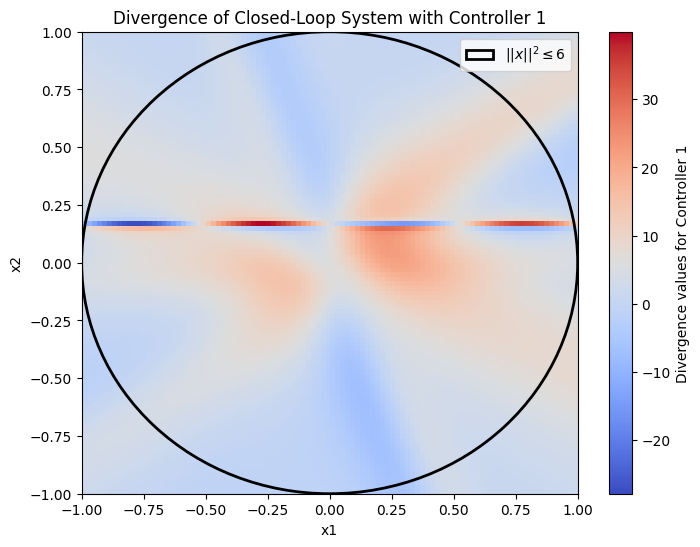

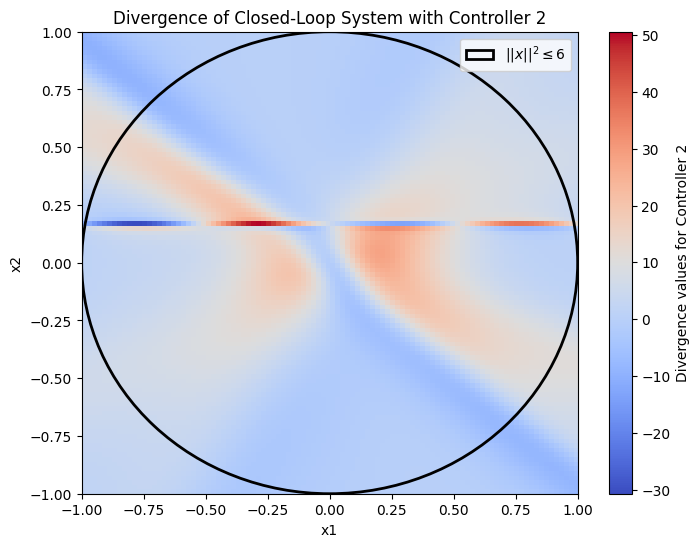

In [20]:
# plot the divergence of (f+gu) for both controllers, i.e u = c/a and u = c1/a1
# and \nabla \cdot (f+gu)= div f + u div g + g^T \nabla (u)
# since u= c/a, \nabla u = (a \nabla c - c \nabla a)/a^2
import matplotlib.patches as patches
grid_size = 100
# Define grid for x1 and x2
x1 = torch.linspace(-6, 6, grid_size)
x2 = torch.linspace(-6, 6, grid_size)
x1_grid, x2_grid = torch.meshgrid(x1, x2)
grid_points = torch.stack([x1_grid.ravel(), x2_grid.ravel()], dim=1).to(device)

def divergence_of_closed_system(x, f_fun, g_fun, a_fun, c_fun):
    ret_val = []
    for i in range(x.shape[0]):
        divergence_at_f = div_f(x[i])
        divergence_at_g = div_g(x[i])
        grad_at_a = gradient_at_given_function(a_fun, x[i])
        grad_at_c = gradient_at_given_function(c_fun, x[i])
        
        a_vals = a_fun(x[i])
        c_vals = c_fun(x[i])
        g_vals = g_fun(x[i])
        # compute \nabla u
        term1 = (a_vals * grad_at_c - c_vals * grad_at_a) / (a_vals ** 2)
        term2 = g_vals @ term1
        term = divergence_at_f + divergence_at_g * (c_vals / a_vals) + term2
        ret_val.append(term)
    ret_val = torch.stack(ret_val)
    return ret_val

divergence_set_controller_1 = divergence_of_closed_system(grid_points, f, g, a_net, c_net)
divergence_set_controller_2 = divergence_of_closed_system(grid_points, f, g, a_net1, c_net1)
# divergence_set_controller_1 = torch.where(divergence_set_controller_1 < 0, -1, 1)
# divergence_set_controller_2 = torch.where(divergence_set_controller_2 < 0, -1, 1)
# plot the values of divergence_set as done for violations
divergence_set_1 = divergence_set_controller_1.detach().cpu().numpy().reshape(grid_size, grid_size)
divergence_set_2 = divergence_set_controller_2.detach().cpu().numpy().reshape(grid_size, grid_size)
# Plot heatmap for controller 1
plt.figure(figsize=(8, 6))
plt.imshow(
    divergence_set_1,
    extent=[-1, 1, -1, 1],
    origin='lower',
    cmap='coolwarm',
    aspect='auto'
)
plt.colorbar(label="Divergence values for Controller 1")
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Divergence of Closed-Loop System with Controller 1")
# Add a circle to the plot
# Add a circle to the plot
circle = patches.Circle((0, 0), 1, color='black', fill=False, linewidth=2, label="$||x||^2 \leq 6$")
plt.gca().add_patch(circle)

# Add legend for the circle
plt.legend(loc='upper right')

plt.grid(False)
plt.show()
# Plot heatmap for controller 2
plt.figure(figsize=(8, 6))
plt.imshow(
    divergence_set_2,
    extent=[-1, 1, -1, 1],
    origin='lower',
    cmap='coolwarm',
    aspect='auto'
)
plt.colorbar(label="Divergence values for Controller 2")
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Divergence of Closed-Loop System with Controller 2")
# Add a circle to the plot
circle = patches.Circle((0, 0), 1, color='black', fill=False, linewidth=2, label="$||x||^2 \leq 6$")
plt.gca().add_patch(circle)
# Add legend for the circle
plt.legend(loc='upper right')
plt.grid(False)
plt.show()


/tmp/ipykernel_16903/1139454339.py:19: UserWarning: The following kwargs were not used by contour: 'label'
  ax.contour(X,Y,rho_set-density_threshold,levels=0,colors='black', linewidths=2,linestyles='solid', label='Mixed Density')
/tmp/ipykernel_16903/1139454339.py:55: RuntimeWarning: invalid value encountered in divide
  DY = DY / magnitude


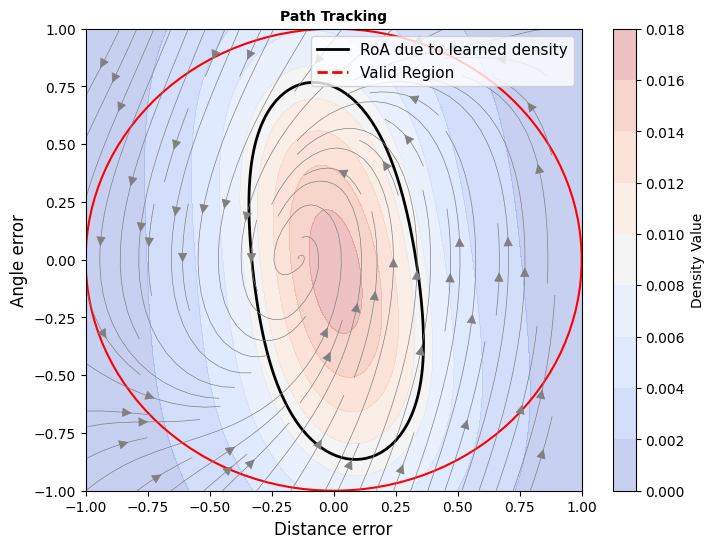

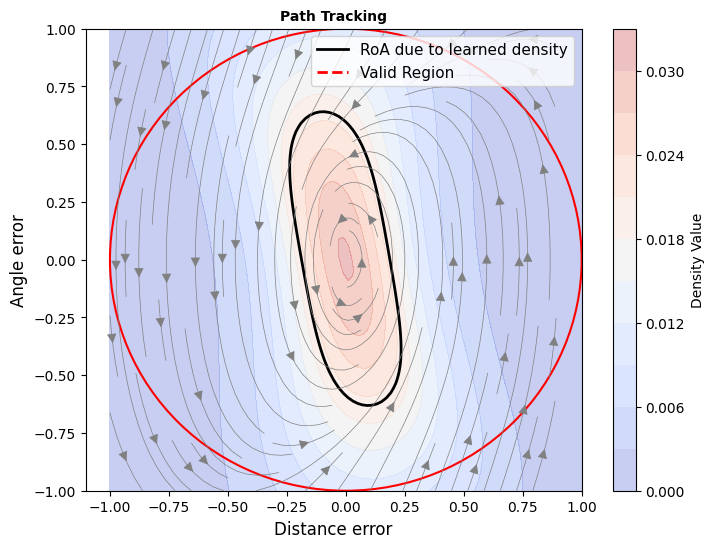

(<Figure size 800x600 with 2 Axes>,
 <Axes: title={'center': 'Path Tracking'}, xlabel='Distance error', ylabel='Angle error'>)

In [23]:
def plot_density_countours(a_nn, b_nn, c_nn,density_threshold, device, plot_flow=True):
    # create meshgrid
    x1 = torch.linspace(-1, 1, 100)
    x2 = torch.linspace(-1, 1, 100)
    X, Y = np.meshgrid(x1,x2)

    # Convert to torch tensor
    grid_points = torch.tensor(np.column_stack([X.ravel(), Y.ravel()]), dtype=torch.float32).to(device)

    # compute the modified density function
    with torch.no_grad():
        rho_set = a_nn(grid_points) / (torch.exp( torch.sum(grid_points**2, dim=1, keepdim=True) + torch.sum((b_nn(grid_points))**2, dim=1, keepdim=True)))
        rho_set = rho_set.squeeze()
        rho_set = rho_set.cpu().numpy().reshape(X.shape)
    # plot the density function
    fig, ax = plt.subplots(figsize=(8, 6))
    # contours = ax.contour(X, Y, rho_set, levels=10, colors='k')

    ax.contour(X,Y,rho_set-density_threshold,levels=0,colors='black', linewidths=2,linestyles='solid', label='Mixed Density')

    filled_contours = ax.contourf(X, Y, rho_set, levels=10, alpha=0.3, cmap=cm.coolwarm)
    plt.colorbar(filled_contours, label='Density Value')

    if plot_flow:
        # create coarser grid for flow field
        x1_flow = np.linspace(-1, 1, 20)
        x2_flow = np.linspace(-1, 1, 20)
        X_flow, Y_flow = np.meshgrid(x1_flow, x2_flow)
        flow_points = torch.tensor(np.column_stack([X_flow.ravel(), Y_flow.ravel()]), dtype=torch.float32).to(device)

        # evaluate control policy u
        with torch.no_grad():
            u_values = c_nn(flow_points) / a_nn(flow_points)
               
        # Calculate vector field
        DX = np.zeros_like(X_flow)
        DY = np.zeros_like(Y_flow)
        
        for i in range(len(x1_flow)):
            for j in range(len(x2_flow)):
                idx = i * len(x1_flow) + j
                x = torch.tensor([X_flow[i, j], Y_flow[i, j]], device=device)
                f_val = f(x)
                g_val = g(x)
                u = u_values[idx]
                
                # Compute flow: f(x) + g(x)u
                flow = f_val + g_val * u
                DX[i, j] = flow[0].cpu().numpy()
                DY[i, j] = flow[1].cpu().numpy()
        
        # Normalize vectors for better visualization
        magnitude = np.sqrt(DX**2 + DY**2)
        DX = DX / magnitude
        DY = DY / magnitude
        
        # Plot flow field
        ax.streamplot(X_flow, Y_flow, DX, DY, color='gray', linewidth=0.5,
                     density=1.0, arrowstyle='<|-', arrowsize=1.5)
    
    # Add valid region circle
    circle = plt.Circle((0, 0), 1, color='r', fill=False, linewidth=1.5, label='Valid Region')
    ax.add_artist(circle)
    
    # Customize plot
    ax.set_xlabel('Distance error', fontsize=12)
    ax.set_ylabel('Angle error', fontsize=12)
    ax.set_title('Path Tracking', fontsize=10, fontweight='bold')
    from matplotlib.lines import Line2D
    legend_elements = [
        Line2D([0], [0], color='black', linewidth=2, linestyle='-', label='RoA due to learned density'),
        Line2D([0], [0], color='red', linewidth=2, linestyle='--', label='Valid Region')
    ]
    ax.legend(handles=legend_elements, loc='upper right', fontsize=11)
    
    
    
    plt.show()
    
    return fig, ax

# Call the function to plot density contours and flow field
plot_density_countours(a_net, b_net, c_net,9e-3, device, plot_flow=True)


# Call the function to plot density contours and flow field
plot_density_countours(a_net1, b_net1, c_net1,5e-2, device, plot_flow=True)





    

# Combined Controllers


/tmp/ipykernel_16903/1554061925.py:20: UserWarning: The following kwargs were not used by contour: 'label'
  ax.contour(X,Y,rho_set-density_threshold,levels=0,colors='black', linewidths=2,linestyles='solid', label='Mixed Density')
/tmp/ipykernel_16903/1554061925.py:61: RuntimeWarning: invalid value encountered in divide
  DY = DY / magnitude


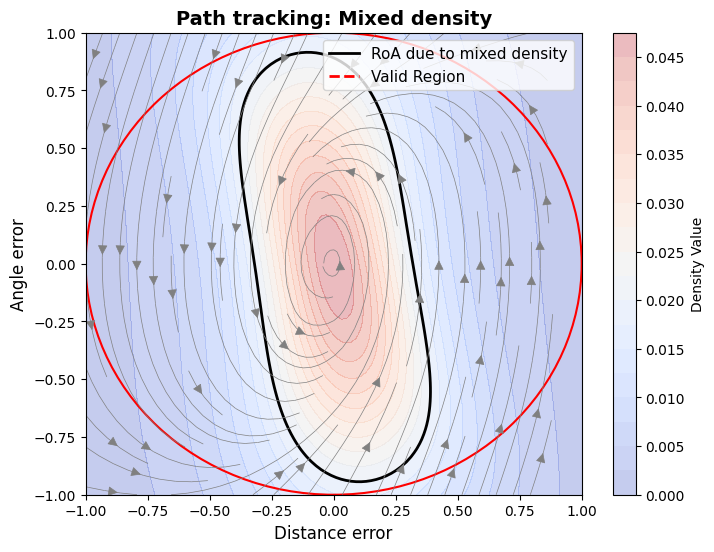

(<Figure size 800x600 with 2 Axes>,
 <Axes: title={'center': 'Path tracking: Mixed density'}, xlabel='Distance error', ylabel='Angle error'>)

In [24]:
def plot_mixed_density_countours(a_nn, b_nn, c_nn,a_nn1,b_nn1,c_nn1, density_threshold, device, plot_flow=True):
    # create meshgrid
    x1 = torch.linspace(-1, 1, 100)
    x2 = torch.linspace(-1, 1, 100)
    X, Y = np.meshgrid(x1,x2)

    # Convert to torch tensor
    grid_points = torch.tensor(np.column_stack([X.ravel(), Y.ravel()]), dtype=torch.float32).to(device)

    # compute the modified density function
    with torch.no_grad():
        rho_set1 = a_nn(grid_points) / (torch.exp( torch.sum(grid_points**2, dim=1, keepdim=True) + torch.sum((b_nn(grid_points))**2, dim=1, keepdim=True)))
        rho_set2 = a_nn1(grid_points) / (torch.exp( torch.sum(grid_points**2, dim=1, keepdim=True) + torch.sum((b_nn1(grid_points))**2, dim=1, keepdim=True)))
        rho_set =  rho_set1+rho_set2
        rho_set = rho_set.squeeze()
        rho_set = rho_set.cpu().numpy().reshape(X.shape)
    # plot the density function
    fig, ax = plt.subplots(figsize=(8, 6))
    
    ax.contour(X,Y,rho_set-density_threshold,levels=0,colors='black', linewidths=2,linestyles='solid', label='Mixed Density')
    filled_contours = ax.contourf(X, Y, rho_set, levels=20, alpha=0.3, cmap=cm.coolwarm)
    plt.colorbar(filled_contours, label='Density Value')

    if plot_flow:
        # create coarser grid for flow field
        x1_flow = np.linspace(-1, 1, 20)
        x2_flow = np.linspace(-1, 1, 20)
        X_flow, Y_flow = np.meshgrid(x1_flow, x2_flow)
        flow_points = torch.tensor(np.column_stack([X_flow.ravel(), Y_flow.ravel()]), dtype=torch.float32).to(device)

        # evaluate control policy u
        with torch.no_grad():
            rho_set1 = a_nn(flow_points) / (torch.exp( torch.sum(flow_points**2, dim=1, keepdim=True) + torch.sum((b_nn(flow_points))**2, dim=1, keepdim=True)))
            rho_set2 = a_nn1(flow_points) / (torch.exp( torch.sum(flow_points**2, dim=1, keepdim=True) + torch.sum((b_nn1(flow_points))**2, dim=1, keepdim=True)))
            u_values1 = c_nn(flow_points) / a_nn(flow_points)
            u_values2 = c_nn1(flow_points) / a_nn1(flow_points)
            weight1 = rho_set1 / (rho_set1+rho_set2)
            weight2 = rho_set2 / (rho_set1+rho_set2)
            u_values = weight1 * u_values1 + weight2 * u_values2
               
        # Calculate vector field
        DX = np.zeros_like(X_flow)
        DY = np.zeros_like(Y_flow)
        
        for i in range(len(x1_flow)):
            for j in range(len(x2_flow)):
                idx = i * len(x1_flow) + j
                x = torch.tensor([X_flow[i, j], Y_flow[i, j]], device=device)
                f_val = f(x)
                g_val = g(x)
                u = u_values[idx]
                
                # Compute flow: f(x) + g(x)u
                flow = f_val + g_val * u
                DX[i, j] = flow[0].cpu().numpy()
                DY[i, j] = flow[1].cpu().numpy()
        
        # Normalize vectors for better visualization
        magnitude = np.sqrt(DX**2 + DY**2)
        DX = DX / magnitude
        DY = DY / magnitude
        
        # Plot flow field
        ax.streamplot(X_flow, Y_flow, DX, DY, color='gray', linewidth=0.5,
                     density=1.0, arrowstyle='<|-', arrowsize=1.5)
    
    # Add valid region circle
    circle = plt.Circle((0, 0), 1, color='r', fill=False, linewidth=1.5, label='Valid Region')
    ax.add_artist(circle)
    
    # Customize plot
    ax.set_xlabel('Distance error', fontsize=12)
    ax.set_ylabel('Angle error', fontsize=12)
    ax.set_title('Path tracking: Mixed density', fontsize=14, fontweight='bold')
    from matplotlib.lines import Line2D
    legend_elements = [
        Line2D([0], [0], color='black', linewidth=2, linestyle='-', label='RoA due to mixed density'),
        Line2D([0], [0], color='red', linewidth=2, linestyle='--', label='Valid Region')
    ]
    ax.legend(handles=legend_elements, loc='upper right', fontsize=11)
    
    
   
    
    plt.show()
    
    return fig, ax


# Call the function to plot density contours and flow field
plot_mixed_density_countours(a_net, b_net, c_net,a_net1,b_net1,c_net1, 7e-2, device, plot_flow=True)



# Mixing the lyapunov controllers with density
$$
    V(x)^{-\alpha}=\rho(x)
$$

We will simply choose $\alpha=1$ and

 $V = tanh((0.099664619999999995 + 0.6251369 * tanh((-1.2775723999999999 - 2.5249655 * x1 - 0.18407556 * x2)) - 1.0490067000000001 * tanh((-0.46410936000000003 - 0.47741896 * x1 - 0.69643679999999997 * x2)) - 1.0708085000000001 * tanh((-0.3698631 - 0.52394079999999998 * x1 - 0.58617014000000001 * x2)) + 0.46437746000000002 * tanh((0.91936094000000002 - 0.023182843000000002 * x1 - 0.50320260000000006 * x2)) + 0.70194889999999999 * tanh((0.97582674000000003 - 0.062661019999999998 * x1 - 0.56203824000000002 * x2)) - 1.1286860000000001 * tanh((1.3282121 + 1.3561938 * x1 + 2.5183802000000002 * x2))))-0.27$

and controller corresponding to this certificate is $u = -0.8471*x1 + -1.6414*x2$


In [18]:
import math 

In [19]:
def tanh(x):
    return (torch.exp(x) - torch.exp(-x)) / (torch.exp(x) + torch.exp(-x))

def lyapunov(x):
    V= tanh((0.099664619999999995 + 0.6251369 * tanh((-1.2775723999999999 - 2.5249655 * x[0] - 0.18407556 * x[1])) - 1.0490067000000001 * tanh((-0.46410936000000003 - 0.47741896 * x[0] - 0.69643679999999997 * x[1])) - 1.0708085000000001 * tanh((-0.3698631 - 0.52394079999999998 * x[0] - 0.58617014000000001 * x[1])) + 0.46437746000000002 * tanh((0.91936094000000002 - 0.023182843000000002 * x[0] - 0.50320260000000006 * x[1])) + 0.70194889999999999 * tanh((0.97582674000000003 - 0.062661019999999998 * x[0] - 0.56203824000000002 * x[1])) - 1.1286860000000001 * tanh((1.3282121 + 1.3561938 * x[0] + 2.5183802000000002 * x[1]))))-0.27
    return V 


def get_density(x, alpha):
    density = 1/ lyapunov(x)
    density = density ** alpha 
    return density 

In [20]:
def lyapunov_controller(x):
    """Certified controller from the Lyapunov function"""
    return -0.8471 * x[0] - 1.6414 * x[1]

def plot_lyapunov_density_and_flow(density_threshold, device, alpha=1, plot_flow=True):
    # create meshgrid
    x1 = torch.linspace(-1, 1, 100)
    x2 = torch.linspace(-1, 1, 100)
    X, Y = np.meshgrid(x1, x2)

    # Convert to torch tensor
    grid_points = torch.tensor(np.column_stack([X.ravel(), Y.ravel()]),
                               dtype=torch.float32).to(device)

    # compute density
    with torch.no_grad():
        rho_vals = []
        for gp in grid_points:
            rho_vals.append(get_density(gp, alpha).cpu().numpy())
        rho_vals = np.array(rho_vals).reshape(X.shape)

    # plot the density function
    fig, ax = plt.subplots(figsize=(8, 6))
    ax.contour(X,Y,rho_vals-density_threshold,levels=0,colors='black', linewidths=2,linestyles='solid', label='Density due to lyapunov')

    filled_contours = ax.contourf(X, Y, rho_vals, levels=10, alpha=0.3, cmap=cm.viridis)
    plt.colorbar(filled_contours, label='Density Value')

    if plot_flow:
        # coarser grid for flow field
        x1_flow = np.linspace(-1, 1, 20)
        x2_flow = np.linspace(-1, 1, 20)
        X_flow, Y_flow = np.meshgrid(x1_flow, x2_flow)

        DX, DY = np.zeros_like(X_flow), np.zeros_like(Y_flow)

        for i in range(len(x1_flow)):
            for j in range(len(x2_flow)):
                x = torch.tensor([X_flow[i, j], Y_flow[i, j]], device=device)
                f_val = f(x)
                g_val = g(x)
                u_val = lyapunov_controller(x)
                flow = f_val + g_val * u_val
                DX[i, j] = flow[0].cpu().numpy()
                DY[i, j] = flow[1].cpu().numpy()

        # normalize vectors
        magnitude = np.sqrt(DX**2 + DY**2)
        DX, DY = DX / (magnitude + 1e-8), DY / (magnitude + 1e-8)

        ax.streamplot(X_flow, Y_flow, DX, DY, color='gray',
                      linewidth=0.5, density=1.0,
                      arrowstyle='-|>', arrowsize=1.5)

    # valid region circle
    circle = plt.Circle((0, 0), 1, color='r', fill=False, linewidth=1.5, label='Valid Region')
    ax.add_artist(circle)

    ax.set_xlabel('Distance error', fontsize=12)
    ax.set_ylabel('Angle error', fontsize=12)
    ax.set_title('Path tracking: Lyapunov based density', fontsize=14, fontweight='bold')
    from matplotlib.lines import Line2D
    legend_elements = [
        Line2D([0], [0], color='black', linewidth=2, linestyle='-', label='RoA due to lyapunov density'),
        Line2D([0], [0], color='red', linewidth=2, linestyle='--', label='Valid Region')
    ]
    ax.legend(handles=legend_elements, loc='upper right', fontsize=11)
    
    
    plt.show()

    return fig, ax




/tmp/ipykernel_16903/119868352.py:24: UserWarning: The following kwargs were not used by contour: 'label'
  ax.contour(X,Y,rho_vals-density_threshold,levels=0,colors='black', linewidths=2,linestyles='solid', label='Density due to lyapunov')
/tmp/ipykernel_16903/119868352.py:49: RuntimeWarning: invalid value encountered in divide
  DX, DY = DX / (magnitude + 1e-8), DY / (magnitude + 1e-8)


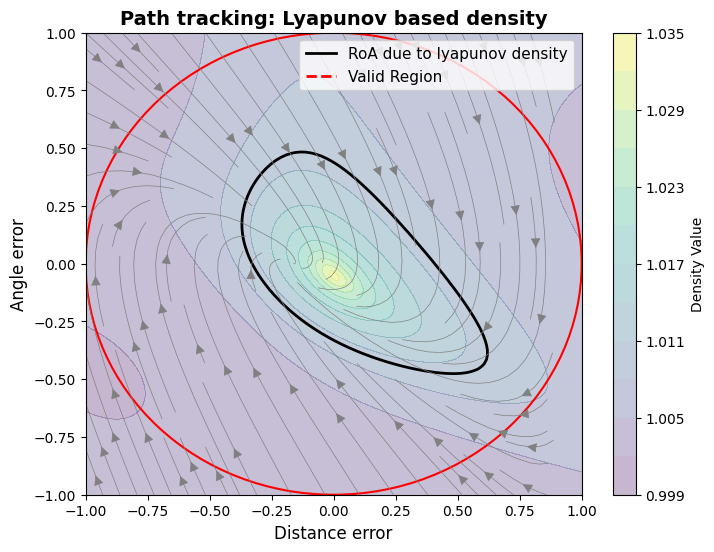

(<Figure size 800x600 with 2 Axes>,
 <Axes: title={'center': 'Path tracking: Lyapunov based density'}, xlabel='Distance error', ylabel='Angle error'>)

In [28]:
plot_lyapunov_density_and_flow(1e-2,device, alpha=0.005, plot_flow=True)

/tmp/ipykernel_16903/2303851352.py:68: RuntimeWarning: invalid value encountered in divide
  DX, DY = DX / (magnitude + 1e-8), DY / (magnitude + 1e-8)


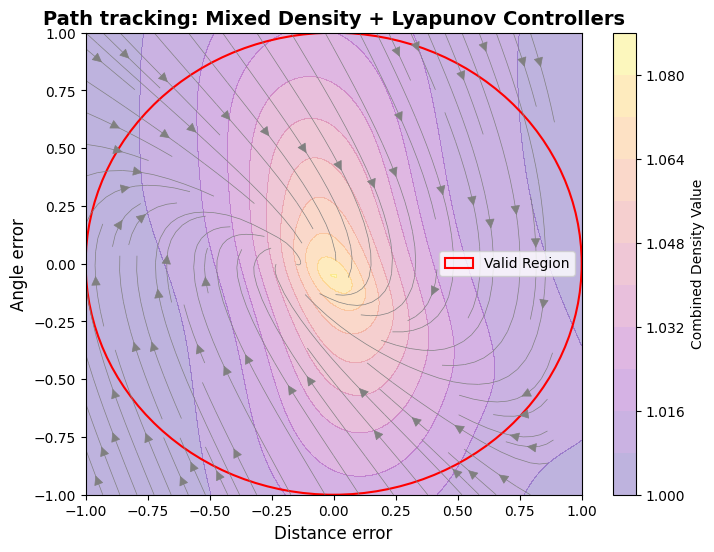

(<Figure size 800x600 with 2 Axes>,
 <Axes: title={'center': 'Path tracking: Mixed Density + Lyapunov Controllers'}, xlabel='Distance error', ylabel='Angle error'>)

In [29]:
def plot_mixed_with_lyapunov(a_nn, b_nn, c_nn,
                             a_nn1, b_nn1, c_nn1,
                             device, alpha=1, plot_flow=True):

    # create meshgrid
    x1 = torch.linspace(-1, 1, 100)
    x2 = torch.linspace(-1, 1, 100)
    X, Y = np.meshgrid(x1, x2)

    grid_points = torch.tensor(np.column_stack([X.ravel(), Y.ravel()]),
                               dtype=torch.float32).to(device)

    with torch.no_grad():
        # densities
        rho1 =  a_nn(grid_points) / (torch.exp(torch.sum(grid_points**2, dim=1, keepdim=True)
                                              + torch.sum((b_nn(grid_points))**2, dim=1, keepdim=True)))
        rho2 = a_nn1(grid_points) / (torch.exp(torch.sum(grid_points**2, dim=1, keepdim=True)
                                               + torch.sum((b_nn1(grid_points))**2, dim=1, keepdim=True)))
        rho3 = torch.stack([get_density(gp, alpha) for gp in grid_points]).to(device).unsqueeze(1)


        rho_total = rho1 + rho2 + rho3
        rho_vals = rho_total.squeeze().cpu().numpy().reshape(X.shape)

    # plot combined density contours
    fig, ax = plt.subplots(figsize=(8, 6))
    filled_contours = ax.contourf(X, Y, rho_vals, levels=10, alpha=0.3, cmap=cm.plasma)
    plt.colorbar(filled_contours, label='Combined Density Value')

    if plot_flow:
        # flow field
        x1_flow = np.linspace(-1, 1, 20)
        x2_flow = np.linspace(-1, 1, 20)
        X_flow, Y_flow = np.meshgrid(x1_flow, x2_flow)
        flow_points = torch.tensor(np.column_stack([X_flow.ravel(), Y_flow.ravel()]),
                                   dtype=torch.float32).to(device)

        with torch.no_grad():
            rho1 = a_nn(flow_points) / (torch.exp(torch.sum(flow_points**2, dim=1, keepdim=True)
                                                  + torch.sum((b_nn(flow_points))**2, dim=1, keepdim=True)))
            rho2 = a_nn1(flow_points) / (torch.exp(torch.sum(flow_points**2, dim=1, keepdim=True)
                                                   + torch.sum((b_nn1(flow_points))**2, dim=1, keepdim=True)))
            rho3 = torch.stack([get_density(gp, alpha) for gp in flow_points]).to(device).unsqueeze(1)


            rho_total =  rho1 + rho2 + rho3
            w1, w2, w3 = rho1 / rho_total, rho2 / rho_total, rho3 / rho_total

            u1 = c_nn(flow_points) / a_nn(flow_points)
            u2 = c_nn1(flow_points) / a_nn1(flow_points)
            u3 = torch.stack([lyapunov_controller(gp) for gp in flow_points]).to(device).unsqueeze(1)


            u_values = w1 * u1 + w2 * u2 + w3 * u3

        DX, DY = np.zeros_like(X_flow), np.zeros_like(Y_flow)
        for i in range(len(x1_flow)):
            for j in range(len(x2_flow)):
                idx = i * len(x1_flow) + j
                x = torch.tensor([X_flow[i, j], Y_flow[i, j]], device=device)
                f_val = f(x)
                g_val = g(x)
                u = u_values[idx]
                flow = f_val + g_val * u
                DX[i, j], DY[i, j] = flow[0].cpu().numpy(), flow[1].cpu().numpy()

        magnitude = np.sqrt(DX**2 + DY**2)
        DX, DY = DX / (magnitude + 1e-8), DY / (magnitude + 1e-8)

        ax.streamplot(X_flow, Y_flow, DX, DY, color='gray',
                      linewidth=0.5, density=1.0,
                      arrowstyle='-|>', arrowsize=1.5)

    circle = plt.Circle((0, 0), 1, color='r', fill=False, linewidth=1.5, label='Valid Region')
    ax.add_artist(circle)

    ax.set_xlabel('Distance error', fontsize=12)
    ax.set_ylabel('Angle error', fontsize=12)
    ax.set_title('Path tracking: Mixed Density + Lyapunov Controllers', fontsize=14, fontweight='bold')
    ax.legend()
    
    plt.show()

    return fig, ax

plot_mixed_with_lyapunov(a_net, b_net, c_net, a_net1,b_net1,c_net1,device,alpha=0.005)

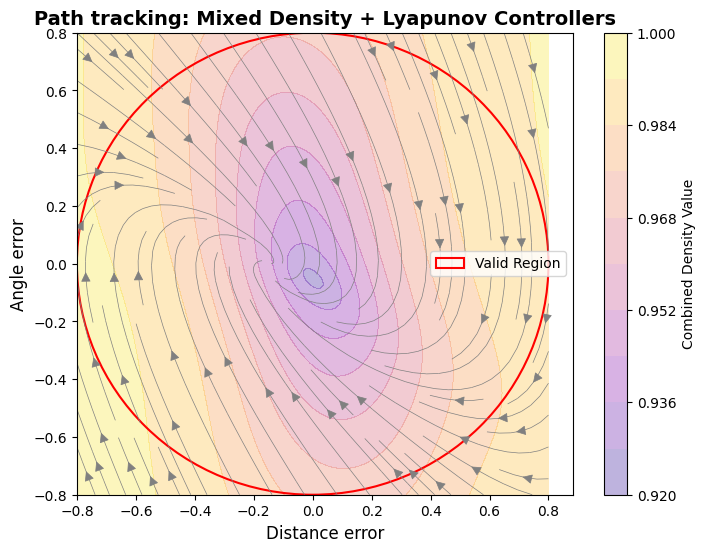

(<Figure size 800x600 with 2 Axes>,
 <Axes: title={'center': 'Path tracking: Mixed Density + Lyapunov Controllers'}, xlabel='Distance error', ylabel='Angle error'>)

In [30]:
def plot_mixed_with_lyapunov(a_nn, b_nn, c_nn,
                             a_nn1, b_nn1, c_nn1,
                             device, alpha=1, plot_flow=True):

    # create meshgrid
    x1 = torch.linspace(-0.8, 0.8, 100)
    x2 = torch.linspace(-0.8, 0.8, 100)
    X, Y = np.meshgrid(x1, x2)

    grid_points = torch.tensor(np.column_stack([X.ravel(), Y.ravel()]),
                               dtype=torch.float32).to(device)

    with torch.no_grad():
        # densities
        rho1 =  a_nn(grid_points) / (torch.exp(torch.sum(grid_points**2, dim=1, keepdim=True)
                                              + torch.sum((b_nn(grid_points))**2, dim=1, keepdim=True)))
        rho2 = a_nn1(grid_points) / (torch.exp(torch.sum(grid_points**2, dim=1, keepdim=True)
                                               + torch.sum((b_nn1(grid_points))**2, dim=1, keepdim=True)))
        rho3 = torch.stack([get_density(gp, alpha) for gp in grid_points]).to(device).unsqueeze(1)


        rho_total = rho1 + rho2 + rho3
        rho_total = 1 / rho_total
        rho_vals = rho_total.squeeze().cpu().numpy().reshape(X.shape)

    # plot combined density contours
    fig, ax = plt.subplots(figsize=(8, 6))
    filled_contours = ax.contourf(X, Y, rho_vals, levels=10, alpha=0.3, cmap=cm.plasma)
    plt.colorbar(filled_contours, label='Combined Density Value')

    if plot_flow:
        # flow field
        x1_flow = np.linspace(-0.8, 0.8, 20)
        x2_flow = np.linspace(-0.8, 0.8, 20)
        X_flow, Y_flow = np.meshgrid(x1_flow, x2_flow)
        flow_points = torch.tensor(np.column_stack([X_flow.ravel(), Y_flow.ravel()]),
                                   dtype=torch.float32).to(device)

        with torch.no_grad():
            rho1 = a_nn(flow_points) / (torch.exp(torch.sum(flow_points**2, dim=1, keepdim=True)
                                                  + torch.sum((b_nn(flow_points))**2, dim=1, keepdim=True)))
            rho2 = a_nn1(flow_points) / (torch.exp(torch.sum(flow_points**2, dim=1, keepdim=True)
                                                   + torch.sum((b_nn1(flow_points))**2, dim=1, keepdim=True)))
            rho3 = torch.stack([get_density(gp, alpha) for gp in flow_points]).to(device).unsqueeze(1)


            rho_total =  rho1 + rho2 + rho3
            w1, w2, w3 = rho1 / rho_total, rho2 / rho_total, rho3 / rho_total

            u1 = c_nn(flow_points) / a_nn(flow_points)
            u2 = c_nn1(flow_points) / a_nn1(flow_points)
            u3 = torch.stack([lyapunov_controller(gp) for gp in flow_points]).to(device).unsqueeze(1)


            u_values = w1 * u1 + w2 * u2 + w3 * u3

        DX, DY = np.zeros_like(X_flow), np.zeros_like(Y_flow)
        for i in range(len(x1_flow)):
            for j in range(len(x2_flow)):
                idx = i * len(x1_flow) + j
                x = torch.tensor([X_flow[i, j], Y_flow[i, j]], device=device)
                f_val = f(x)
                g_val = g(x)
                u = u_values[idx]
                flow = f_val + g_val * u
                DX[i, j], DY[i, j] = flow[0].cpu().numpy(), flow[1].cpu().numpy()

        magnitude = np.sqrt(DX**2 + DY**2)
        DX, DY = DX / (magnitude + 1e-8), DY / (magnitude + 1e-8)

        ax.streamplot(X_flow, Y_flow, DX, DY, color='gray',
                      linewidth=0.5, density=1.0,
                      arrowstyle='-|>', arrowsize=1.5)

    circle = plt.Circle((0, 0), 0.8, color='r', fill=False, linewidth=1.5, label='Valid Region')
    ax.add_artist(circle)

    ax.set_xlabel('Distance error', fontsize=12)
    ax.set_ylabel('Angle error', fontsize=12)
    ax.set_title('Path tracking: Mixed Density + Lyapunov Controllers', fontsize=14, fontweight='bold')
    ax.legend()
   
    plt.show()

    return fig, ax

plot_mixed_with_lyapunov(a_net, b_net, c_net, a_net1,b_net1,c_net1,device,alpha=0.005)

In [31]:
def plot_mixed_with_lyapunov(a_nn, b_nn, c_nn,
                             a_nn1, b_nn1, c_nn1,density_threshold,
                             device, alpha=1, plot_flow=True):

    # create meshgrid
    x1 = torch.linspace(-0.8, 0.8, 100)
    x2 = torch.linspace(-0.8, 0.8, 100)
    X, Y = np.meshgrid(x1, x2)

    grid_points = torch.tensor(np.column_stack([X.ravel(), Y.ravel()]),
                               dtype=torch.float32).to(device)

    with torch.no_grad():
        # densities
        rho1 = 10 * a_nn(grid_points) / (torch.exp(torch.sum(grid_points**2, dim=1, keepdim=True)
                                              + torch.sum((b_nn(grid_points))**2, dim=1, keepdim=True)))
        rho2 = 10 * a_nn1(grid_points) / (torch.exp(torch.sum(grid_points**2, dim=1, keepdim=True)
                                               + torch.sum((b_nn1(grid_points))**2, dim=1, keepdim=True)))
        rho3 = torch.stack([get_density(gp, alpha) for gp in grid_points]).to(device).unsqueeze(1)


        rho_total = rho1 + rho2 + rho3
        rho_vals = rho_total.squeeze().cpu().numpy().reshape(X.shape)

    # plot combined density contours
    fig, ax = plt.subplots(figsize=(8, 6))

    ax.contour(X,Y,rho_vals-density_threshold,levels=0,colors='black', linewidths=2,linestyles='solid', label='Mixed Density')


    # ax.contour(X, Y, rho_vals,  linewidth=0.3)
    filled_contours = ax.contourf(X, Y, rho_vals,levels=10, alpha=0.3,linewidths=0.5, cmap=cm.plasma)

    plt.colorbar(filled_contours, label='Combined Density Value')

    if plot_flow:
        # flow field
        x1_flow = np.linspace(-0.8, 0.8, 20)
        x2_flow = np.linspace(-0.8, 0.8, 20)
        X_flow, Y_flow = np.meshgrid(x1_flow, x2_flow)
        flow_points = torch.tensor(np.column_stack([X_flow.ravel(), Y_flow.ravel()]),
                                   dtype=torch.float32).to(device)

        with torch.no_grad():
            rho1 = 10 * a_nn(flow_points) / (torch.exp(torch.sum(flow_points**2, dim=1, keepdim=True)
                                                  + torch.sum((b_nn(flow_points))**2, dim=1, keepdim=True)))
            rho2 = 10 * a_nn1(flow_points) / (torch.exp(torch.sum(flow_points**2, dim=1, keepdim=True)
                                                   + torch.sum((b_nn1(flow_points))**2, dim=1, keepdim=True)))
            rho3 = torch.stack([get_density(gp, alpha) for gp in flow_points]).to(device).unsqueeze(1)


            rho_total =  rho1 + rho2 + rho3
            w1, w2, w3 = rho1 / rho_total, rho2 / rho_total, rho3 / rho_total

            u1 = c_nn(flow_points) / a_nn(flow_points)
            u2 = c_nn1(flow_points) / a_nn1(flow_points)
            u3 = torch.stack([lyapunov_controller(gp) for gp in flow_points]).to(device).unsqueeze(1)


            u_values = w1 * u1 + w2 * u2 + w3 * u3

        DX, DY = np.zeros_like(X_flow), np.zeros_like(Y_flow)
        for i in range(len(x1_flow)):
            for j in range(len(x2_flow)):
                idx = i * len(x1_flow) + j
                x = torch.tensor([X_flow[i, j], Y_flow[i, j]], device=device)
                f_val = f(x)
                g_val = g(x)
                u = u_values[idx]
                flow = f_val + g_val * u
                DX[i, j], DY[i, j] = flow[0].cpu().numpy(), flow[1].cpu().numpy()

        magnitude = np.sqrt(DX**2 + DY**2)
        DX, DY = DX / (magnitude + 1e-8), DY / (magnitude + 1e-8)

        ax.streamplot(X_flow, Y_flow, DX, DY, color='gray',
                      linewidth=0.5, density=1.0,
                      arrowstyle='-|>', arrowsize=1.5)

    circle = plt.Circle((0, 0), 0.8, color='r', fill=False, linewidth=1.5, label='Valid Region')
    ax.add_artist(circle)

    ax.set_xlabel('Distance error', fontsize=12)
    ax.set_ylabel('Angle error', fontsize=12)
    ax.set_title('Path tracking: Mixed Density + Lyapunov Controllers', fontsize=14, fontweight='bold')
    ax.legend()
   
    plt.show()

    return fig, ax



In [36]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.patches import Circle


def plot_combined_roa(a_nn, b_nn, c_nn, a_nn1, b_nn1, c_nn1, 
                      device, alpha=0.005, 
                      density_threshold=0.55, 
                      lyapunov_threshold=0.27,
                      plot_flow=True):
    """
    Plot both ROAs on the same plot for direct comparison
    """
    
    # Create meshgrid
    x1 = torch.linspace(-1, 1, 200)
    x2 = torch.linspace(-1, 1, 200)
    X, Y = np.meshgrid(x1, x2)

    grid_points = torch.tensor(np.column_stack([X.ravel(), Y.ravel()]),
                               dtype=torch.float32).to(device)

    with torch.no_grad():
        # Compute densities
        rho1 = 10 * a_nn(grid_points) / (
            torch.exp(torch.sum(grid_points**2, dim=1, keepdim=True)
                     + torch.sum((b_nn(grid_points))**2, dim=1, keepdim=True)))
        rho2 = 10 * a_nn1(grid_points) / (
            torch.exp(torch.sum(grid_points**2, dim=1, keepdim=True)
                     + torch.sum((b_nn1(grid_points))**2, dim=1, keepdim=True)))
        rho3 = torch.stack([get_density(gp, alpha) for gp in grid_points]).to(device).unsqueeze(1)

        rho_total = rho1 + rho2 + rho3
        rho_vals = rho_total.squeeze().cpu().numpy().reshape(X.shape)

        mixed_rho = ( rho1 + rho2 ) / 10 
        mixed_rho = mixed_rho.squeeze().cpu().numpy().reshape(X.shape)
        rho_vals = rho_total.squeeze().cpu().numpy().reshape(X.shape)
        rho1 = rho1.squeeze().cpu().numpy().reshape(X.shape)
        rho2 = rho2.squeeze().cpu().numpy().reshape(X.shape)
        
        # Compute Lyapunov values
        lyap_vals = []
        for gp in grid_points:
            lyap_vals.append(lyapunov(gp).cpu().numpy())
        lyap_vals = np.array(lyap_vals).reshape(X.shape)

    # Create single plot
    fig, ax = plt.subplots(figsize=(8, 6))

    # Plot density contours
    filled_contours = ax.contourf(X, Y, rho_vals, alpha=0.3, 
                                  cmap=cm.coolwarm)
    plt.colorbar(filled_contours, ax=ax, label='Combined Density Value')

    # Draw both ROAs
    learned_density_contour1 = ax.contour(X, Y, rho1/10 - 9e-3, levels=0,
                                       colors='magenta', linewidths=2, 
                                       linestyles='--', label='Learned Density ROA')
    learned_density_contour2 = ax.contour(X, Y, rho2/10 - 5e-2, levels=0,
                                       colors='magenta', linewidths=2, 
                                       linestyles='--', label='Learned Density ROA')
    mixed_density_contour = ax.contour(X, Y, mixed_rho - 7e-2, levels=0,
                                       colors='blue', linewidths=2, 
                                       linestyles='solid', label='Learned Density ROA')
    
    contour_density = ax.contour(X, Y, rho_vals-density_threshold, levels=0,
                                colors='black', linewidths=2, 
                                linestyles='solid', label='Density+Lyapunov ROA')
    
    contour_lyap = ax.contour(X, Y, lyap_vals, levels=[lyapunov_threshold], 
                             colors='red', linewidths=2, 
                             linestyles='solid', label='Lyapunov ROA')

    if plot_flow:
        # Flow field
        x1_flow = np.linspace(-1, 1, 20)
        x2_flow = np.linspace(-1, 1, 20)
        X_flow, Y_flow = np.meshgrid(x1_flow, x2_flow)
        flow_points = torch.tensor(np.column_stack([X_flow.ravel(), Y_flow.ravel()]),
                                   dtype=torch.float32).to(device)

        with torch.no_grad():
            rho1_flow = 10 * a_nn(flow_points) / (
                torch.exp(torch.sum(flow_points**2, dim=1, keepdim=True)
                         + torch.sum((b_nn(flow_points))**2, dim=1, keepdim=True)))
            rho2_flow = 10 * a_nn1(flow_points) / (
                torch.exp(torch.sum(flow_points**2, dim=1, keepdim=True)
                         + torch.sum((b_nn1(flow_points))**2, dim=1, keepdim=True)))
            rho3_flow = torch.stack([get_density(gp, alpha) for gp in flow_points]).to(device).unsqueeze(1)

            rho_total_flow = rho1_flow + rho2_flow + rho3_flow
            w1, w2, w3 = rho1_flow / rho_total_flow, rho2_flow / rho_total_flow, rho3_flow / rho_total_flow

            u1 = c_nn(flow_points) / a_nn(flow_points)
            u2 = c_nn1(flow_points) / a_nn1(flow_points)
            u3 = torch.stack([lyapunov_controller(gp) for gp in flow_points]).to(device).unsqueeze(1)

            u_values = w1 * u1 + w2 * u2 + w3 * u3

        DX, DY = np.zeros_like(X_flow), np.zeros_like(Y_flow)
        for i in range(len(x1_flow)):
            for j in range(len(x2_flow)):
                idx = i * len(x1_flow) + j
                x = torch.tensor([X_flow[i, j], Y_flow[i, j]], device=device)
                f_val = f(x)
                g_val = g(x)
                u = u_values[idx]
                flow = f_val + g_val * u
                DX[i, j], DY[i, j] = flow[0].cpu().numpy(), flow[1].cpu().numpy()

        magnitude = np.sqrt(DX**2 + DY**2)
        DX, DY = DX / (magnitude + 1e-8), DY / (magnitude + 1e-8)

        ax.streamplot(X_flow, Y_flow, DX, DY, color='gray',
                     linewidth=0.5, density=1.0,
                     arrowstyle='-|>', arrowsize=1.5)

    # Valid region circle
    circle = Circle((0, 0), 1, color='red', fill=False, 
                   linewidth=2, linestyle='--', label='Valid Region')
    ax.add_artist(circle)

    ax.set_xlabel('Distance error')
    ax.set_ylabel('Angle error')
    ax.set_title('Path Tracking')
    
    # Create custom legend
    from matplotlib.lines import Line2D
    legend_elements = [
        Line2D([0], [0], color='green', linewidth=2, linestyle='--', label='Neural Density Controller 1'),
        Line2D([0], [0], color='magenta', linewidth=2, linestyle='--', label='Neural Density Controller 2'),
        Line2D([0], [0], color='blue', linewidth=2, linestyle='-', label='Mixed Density Controller'),
        Line2D([0], [0], color='black', linewidth=2, linestyle='-', label='Mixed Density Controller + Lyapunov Controller'),
        Line2D([0], [0], color='red', linewidth=2, linestyle='-', label='Lyapunov Controller'),
        Line2D([0], [0], color='red', linewidth=2, linestyle='--', label='Valid Region'),

    ]
    ax.legend(handles=legend_elements, loc='upper right', fontsize=11)
    
    ax.grid(True, alpha=0.3)
    ax.set_aspect('equal')

    plt.tight_layout()
    plt.show()

    return fig, ax



/tmp/ipykernel_16903/894196487.py:59: UserWarning: The following kwargs were not used by contour: 'label'
  learned_density_contour1 = ax.contour(X, Y, rho1/10 - 9e-3, levels=0,
/tmp/ipykernel_16903/894196487.py:62: UserWarning: The following kwargs were not used by contour: 'label'
  learned_density_contour2 = ax.contour(X, Y, rho2/10 - 5e-2, levels=0,
/tmp/ipykernel_16903/894196487.py:65: UserWarning: The following kwargs were not used by contour: 'label'
  mixed_density_contour = ax.contour(X, Y, mixed_rho - 7e-2, levels=0,
/tmp/ipykernel_16903/894196487.py:69: UserWarning: The following kwargs were not used by contour: 'label'
  contour_density = ax.contour(X, Y, rho_vals-density_threshold, levels=0,
/tmp/ipykernel_16903/894196487.py:73: UserWarning: The following kwargs were not used by contour: 'label'
  contour_lyap = ax.contour(X, Y, lyap_vals, levels=[lyapunov_threshold],
/tmp/ipykernel_16903/894196487.py:115: RuntimeWarning: invalid value encountered in divide
  DX, DY = DX /

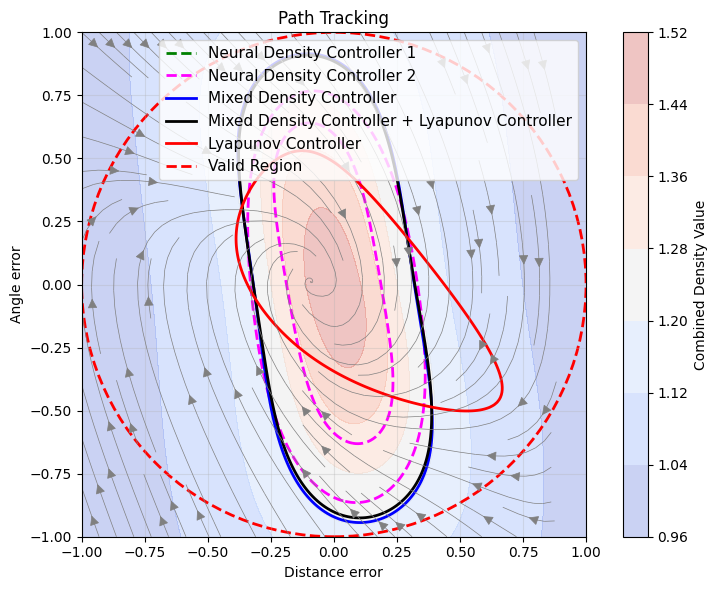

In [37]:


# 2. Combined plot (similar to your reference image)
fig, ax = plot_combined_roa(a_net, b_net, c_net, a_net1, b_net1, c_net1, 
                           device, alpha=0.005, 
                           density_threshold=1e-2, 
                           lyapunov_threshold=0.15)

In [21]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.patches import Circle


def plot_combined_roa(a_nn, b_nn, c_nn, a_nn1, b_nn1, c_nn1, 
                      device, alpha=0.005, 
                      density_threshold=0.55, 
                      lyapunov_threshold=0.27,
                      plot_flow=True):
    """
    Plot both ROAs on the same plot for direct comparison
    """
    
    # Create meshgrid
    x1 = torch.linspace(-1, 1, 200)
    x2 = torch.linspace(-1, 1, 200)
    X, Y = np.meshgrid(x1, x2)

    grid_points = torch.tensor(np.column_stack([X.ravel(), Y.ravel()]),
                               dtype=torch.float32).to(device)

    with torch.no_grad():
        # Compute densities
        rho1 =  a_nn(grid_points) / (
            torch.exp(torch.sum(grid_points**2, dim=1, keepdim=True)
                     + torch.sum((b_nn(grid_points))**2, dim=1, keepdim=True)))
        rho2 =  a_nn1(grid_points) / (
            torch.exp(torch.sum(grid_points**2, dim=1, keepdim=True)
                     + torch.sum((b_nn1(grid_points))**2, dim=1, keepdim=True)))
        rho3 = torch.stack([get_density(gp, alpha) for gp in grid_points]).to(device).unsqueeze(1)
        rho1 = rho1 / max(rho1)
        rho2 = rho2 / max(rho2)
        rho3 = rho3 / max(rho3)

        rho_total = rho1 + rho2 + rho3
        rho_vals = rho_total.squeeze().cpu().numpy().reshape(X.shape)

        mixed_rho = ( rho1 + rho2 ) 
        mixed_rho = mixed_rho.squeeze().cpu().numpy().reshape(X.shape)
        rho_vals = rho_total.squeeze().cpu().numpy().reshape(X.shape)
        rho1 = rho1.squeeze().cpu().numpy().reshape(X.shape)
        rho2 = rho2.squeeze().cpu().numpy().reshape(X.shape)
        
        # Compute Lyapunov values
        lyap_vals = []
        for gp in grid_points:
            lyap_vals.append(lyapunov(gp).cpu().numpy())
        lyap_vals = np.array(lyap_vals).reshape(X.shape)

    # Create single plot
    fig, ax = plt.subplots(figsize=(8, 6))

    # Plot density contours
    filled_contours = ax.contourf(X, Y, rho_vals, alpha=0.3, 
                                  cmap=cm.coolwarm)
    plt.colorbar(filled_contours, ax=ax, label='Combined Density Value')

    # Draw both ROAs
    learned_density_contour1 = ax.contour(X, Y, rho1 - density_threshold, levels=0,
                                       colors='green', linewidths=2, 
                                       linestyles='--', label='Learned Density ROA')
    learned_density_contour2 = ax.contour(X, Y, rho2-density_threshold, levels=0,
                                       colors='magenta', linewidths=2, 
                                       linestyles='--', label='Learned Density ROA')
    mixed_density_contour = ax.contour(X, Y, mixed_rho -density_threshold, levels=0,
                                       colors='blue', linewidths=2, 
                                       linestyles='solid', label='Learned Density ROA')
    
    contour_density = ax.contour(X, Y, rho_vals-density_threshold, levels=0,
                                colors='black', linewidths=2, 
                                linestyles='solid', label='Density+Lyapunov ROA')
    
    contour_lyap = ax.contour(X, Y, lyap_vals, levels=[lyapunov_threshold], 
                             colors='red', linewidths=2, 
                             linestyles='solid', label='Lyapunov ROA')

    if plot_flow:
        # Flow field
        x1_flow = np.linspace(-1, 1, 20)
        x2_flow = np.linspace(-1, 1, 20)
        X_flow, Y_flow = np.meshgrid(x1_flow, x2_flow)
        flow_points = torch.tensor(np.column_stack([X_flow.ravel(), Y_flow.ravel()]),
                                   dtype=torch.float32).to(device)

        with torch.no_grad():
            rho1_flow = a_nn(flow_points) / (
                torch.exp(torch.sum(flow_points**2, dim=1, keepdim=True)
                         + torch.sum((b_nn(flow_points))**2, dim=1, keepdim=True)))
            rho2_flow =  a_nn1(flow_points) / (
                torch.exp(torch.sum(flow_points**2, dim=1, keepdim=True)
                         + torch.sum((b_nn1(flow_points))**2, dim=1, keepdim=True)))
            rho3_flow = torch.stack([get_density(gp, alpha) for gp in flow_points]).to(device).unsqueeze(1)
            rho1_flow = rho1_flow / max(rho1_flow)
            rho2_flow = rho2_flow / max(rho2_flow)
            rho3_flow = rho3_flow / max(rho3_flow)
            
            rho_total_flow = rho1_flow + rho2_flow + rho3_flow
            w1, w2, w3 = rho1_flow / rho_total_flow, rho2_flow / rho_total_flow, rho3_flow / rho_total_flow

            u1 = c_nn(flow_points) / a_nn(flow_points)
            u2 = c_nn1(flow_points) / a_nn1(flow_points)
            u3 = torch.stack([lyapunov_controller(gp) for gp in flow_points]).to(device).unsqueeze(1)

            u_values = w1 * u1 + w2 * u2 + w3 * u3

        DX, DY = np.zeros_like(X_flow), np.zeros_like(Y_flow)
        for i in range(len(x1_flow)):
            for j in range(len(x2_flow)):
                idx = i * len(x1_flow) + j
                x = torch.tensor([X_flow[i, j], Y_flow[i, j]], device=device)
                f_val = f(x)
                g_val = g(x)
                u = u_values[idx]
                flow = f_val + g_val * u
                DX[i, j], DY[i, j] = flow[0].cpu().numpy(), flow[1].cpu().numpy()

        magnitude = np.sqrt(DX**2 + DY**2)
        DX, DY = DX / (magnitude + 1e-8), DY / (magnitude + 1e-8)

        ax.streamplot(X_flow, Y_flow, DX, DY, color='gray',
                     linewidth=0.5, density=1.0,
                     arrowstyle='-|>', arrowsize=1.5)

    # Valid region circle
    circle = Circle((0, 0), 1, color='red', fill=False, 
                   linewidth=2, linestyle='--', label='Valid Region')
    ax.add_artist(circle)

    ax.set_xlabel('Distance error')
    ax.set_ylabel('Angle error')
    ax.set_title('Path Tracking')
    
    # Create custom legend
    from matplotlib.lines import Line2D
    legend_elements = [
        Line2D([0], [0], color='green', linewidth=2, linestyle='--', label='NCDF 1'),
        Line2D([0], [0], color='magenta', linewidth=2, linestyle='--', label='NCDF 2'),
        Line2D([0], [0], color='blue', linewidth=2, linestyle='-', label='Mixed Density Controller'),
        Line2D([0], [0], color='black', linewidth=2, linestyle='-', label='Mixed Density Controller + Lyapunov Controller'),
        Line2D([0], [0], color='red', linewidth=2, linestyle='-', label='Lyapunov Controller'),
        Line2D([0], [0], color='red', linewidth=2, linestyle='--', label='Valid Region'),

    ]
    ax.legend(handles=legend_elements, loc='upper right', fontsize=11)
    
    ax.grid(True, alpha=0.3)
    ax.set_aspect('equal')

    plt.tight_layout()
    plt.show()

    return fig, ax



/tmp/ipykernel_91269/536926521.py:62: UserWarning: The following kwargs were not used by contour: 'label'
  learned_density_contour1 = ax.contour(X, Y, rho1 - density_threshold, levels=0,
/tmp/ipykernel_91269/536926521.py:65: UserWarning: The following kwargs were not used by contour: 'label'
  learned_density_contour2 = ax.contour(X, Y, rho2-density_threshold, levels=0,
/tmp/ipykernel_91269/536926521.py:68: UserWarning: The following kwargs were not used by contour: 'label'
  mixed_density_contour = ax.contour(X, Y, mixed_rho -density_threshold, levels=0,
/tmp/ipykernel_91269/536926521.py:72: UserWarning: The following kwargs were not used by contour: 'label'
  contour_density = ax.contour(X, Y, rho_vals-density_threshold, levels=0,
/tmp/ipykernel_91269/536926521.py:76: UserWarning: The following kwargs were not used by contour: 'label'
  contour_lyap = ax.contour(X, Y, lyap_vals, levels=[lyapunov_threshold],
/tmp/ipykernel_91269/536926521.py:121: RuntimeWarning: invalid value encount

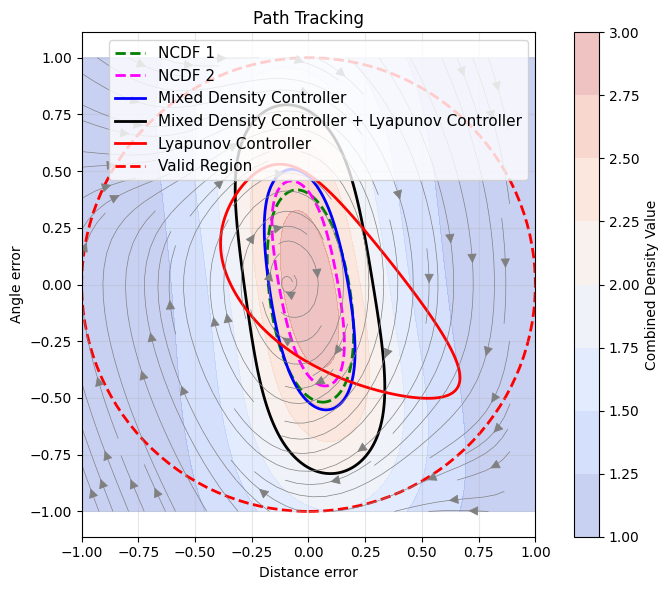

In [22]:


# 2. Combined plot (similar to your reference image)
fig, ax = plot_combined_roa(a_net, b_net, c_net, a_net1, b_net1, c_net1, 
                           device, alpha=0.005, 
                           density_threshold=1e-2, 
                           lyapunov_threshold=0.15)